In [48]:
import math
import statistics
import numpy as np
import pandas as pd
import scipy.stats
from pathlib import Path

## Location

#### Mean

In [2]:
x = [8.0, 1, 2.5, 4,  4, 28.0, math.nan]
y = [8.0, 1, 2.5, 4, 28.0]

In [3]:
sum(x)/len(x), statistics.mean(x), np.mean(x), np.array(x).mean() # all methods will give nan 

(nan, nan, np.float64(nan), np.float64(nan))

In [4]:
pd.Series(x).mean(),  np.nanmean(x) # these methods work with nan - ignores it 

(np.float64(7.916666666666667), np.float64(7.916666666666667))

In [5]:
sum(y)/len(y), statistics.mean(y), np.mean(y), np.array(y).mean()

(8.7, 8.7, np.float64(8.7), np.float64(8.7))

In [6]:
# trimmed mean
scipy.stats.trim_mean([1,2,3,4,5,6,7,8,9,10], 0.1) 

np.float64(5.5)

### Weighted Mean

In [7]:
y
w = [0.1, 0.5, 0.1, 0.1, 0.2]

wmean = sum(w[i] * y[i] for i in range(len(y))) / sum(w)
wmean

7.550000000000001

In [8]:
np.average(y, weights = w)

np.float64(7.550000000000001)

### Median

In [9]:
statistics.median(x)

4

In [10]:
sorted(x)  

[1, 2.5, 4, 4, 8.0, 28.0, nan]

In [11]:
statistics.mode(x), scipy.stats.mode(x)

(4, ModeResult(mode=np.float64(4.0), count=np.int64(2)))

In [12]:
statistics.mode(y) , scipy.stats.mode(y) # here the results are different, because the functions fail if there is no unique mode..each function works differently

(8.0, ModeResult(mode=np.float64(1.0), count=np.int64(1)))

## Variance

In [13]:
statistics.variance(y)

123.2

In [14]:
np.var(y, ddof=1) # degrees of freedom (n-1) -> more degrees of freedom = more variance, also note that statistics.variance by default uses ddof = 1

np.float64(123.19999999999999)

In [15]:
np.var(y) # degrees of freedom = 0

np.float64(98.55999999999999)

In [16]:
np.asarray(y).var()

np.float64(98.55999999999999)

### Std Dev
- its easier to use then variance because it has the same scale as the original series

In [17]:
statistics.stdev(y)

11.099549540409287

In [18]:
np.std(y, ddof = 1), np.std(y) # again compare the ddof

(np.float64(11.099549540409285), np.float64(9.927738916792684))

### Other Metrics

In [44]:
x = [8.0, 1, 2.5, 4, 29.0, 6, 8, 9 ,11,  18, 32]
y = [8.0, 1, 2.5, 4, 28.0]

np.percentile(y, 95)

np.float64(23.999999999999996)

In [45]:
# interquantile range - IQR
a = pd.Series(x)
a.quantile(0.75) - a.quantile(0.25)

np.float64(9.5)

In [33]:
a.quantile([0.75, 0.25])

0.75    10.5
0.25     4.5
dtype: float64

<Axes: >

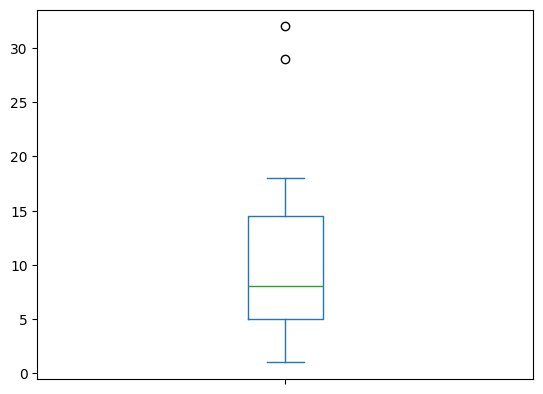

In [46]:
# boxplot...top and bottom of the box are 25th and 75th percentile, median is the horizonatl line in the middle, whiskers go to the further point behind the box, but at max of 1.5 IQR
a.plot.box()

In [23]:
scipy.stats.describe(y)

DescribeResult(nobs=np.int64(5), minmax=(np.float64(1.0), np.float64(28.0)), mean=np.float64(8.7), variance=np.float64(123.19999999999999), skewness=np.float64(1.3061163034727836), kurtosis=np.float64(-0.030495095281138695))

In [24]:
np.cov(y, y)

array([[123.2, 123.2],
       [123.2, 123.2]])

In [25]:
np.corrcoef(y, y)

array([[1., 1.],
       [1., 1.]])

In [26]:
v = pd.Series(x)
u = pd.Series(y)
v.corr(u)

np.float64(0.9999585339467957)

In [27]:

scipy.stats.linregress(x, y)

LinregressResult(slope=np.float64(0.9622322435174747), intercept=np.float64(0.13613303269447385), rvalue=np.float64(0.9999585339467959), pvalue=np.float64(3.205311243855806e-07), stderr=np.float64(0.005059343110789314), intercept_stderr=np.float64(0.06893529046222363))

### 2D data

In [28]:
a = np.array([[1,1,1,],
             [2,3,1],
             [4,9,2],
             [8,27,4],
             [16,1,1]]
             )
np.mean(a, axis = 1), np.mean(a, axis = None)

(array([ 1.,  2.,  5., 13.,  6.]), np.float64(5.4))

In [29]:
np.mean(a, axis = 0)

array([6.2, 8.2, 1.8])

In [30]:
a.mean(axis = 0)  # for each column

array([6.2, 8.2, 1.8])

## Histograms and Density

In [55]:
STATE_CSV = 'state.csv'
file_path_states = Path().resolve() / 'data' / STATE_CSV

states = pd.read_csv(file_path_states)

## Histogram

<Axes: ylabel='Frequency'>

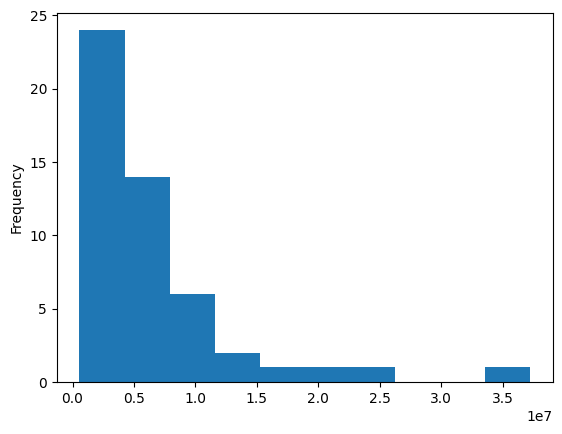

In [59]:
states['Population'].plot.hist()

In [69]:
bins = pd.cut(states['Population'], 5) # will bin the data into 5 equally sized bins
bins

0       (526935.67, 7901692.0]
1       (526935.67, 7901692.0]
2       (526935.67, 7901692.0]
3       (526935.67, 7901692.0]
4     (29915890.0, 37253956.0]
5       (526935.67, 7901692.0]
6       (526935.67, 7901692.0]
7       (526935.67, 7901692.0]
8     (15239758.0, 22577824.0]
9      (7901692.0, 15239758.0]
10      (526935.67, 7901692.0]
11      (526935.67, 7901692.0]
12     (7901692.0, 15239758.0]
13      (526935.67, 7901692.0]
14      (526935.67, 7901692.0]
15      (526935.67, 7901692.0]
16      (526935.67, 7901692.0]
17      (526935.67, 7901692.0]
18      (526935.67, 7901692.0]
19      (526935.67, 7901692.0]
20      (526935.67, 7901692.0]
21     (7901692.0, 15239758.0]
22      (526935.67, 7901692.0]
23      (526935.67, 7901692.0]
24      (526935.67, 7901692.0]
25      (526935.67, 7901692.0]
26      (526935.67, 7901692.0]
27      (526935.67, 7901692.0]
28      (526935.67, 7901692.0]
29     (7901692.0, 15239758.0]
30      (526935.67, 7901692.0]
31    (15239758.0, 22577824.0]
32     (

In [67]:
bins.value_counts()

Population
(526935.67, 7901692.0]      38
(7901692.0, 15239758.0]      8
(15239758.0, 22577824.0]     2
(22577824.0, 29915890.0]     1
(29915890.0, 37253956.0]     1
Name: count, dtype: int64

## Density

<Axes: ylabel='Density'>

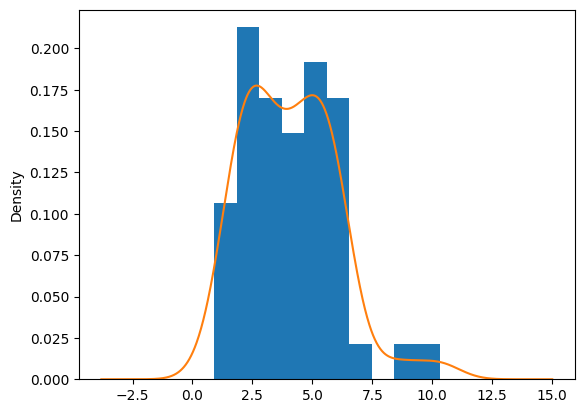

In [75]:
states['Murder.Rate'].plot.hist(density = True) # total area under the density curve = 1, instead of counts in bins....
states['Murder.Rate'].plot.density()

## Correlation

In [91]:
SP500_CSV = 'sp500.csv'
file_path_sp500 = Path().resolve() / 'data' / SP500_CSV
sp500 = pd.read_csv(file_path_sp500, index_col = 0)

In [90]:
sp500.corr()

,ADS,CA,MSFT,RHT,CTSH,CSC,EMC,IBM,XRX,ALTR,...,WAT,ALXN,AMGN,BXLT,BIIB,CELG,GILD,REGN,VRTX,HSIC
ADS,1.000000,0.123881,0.216321,0.138958,0.379913,0.160507,0.075650,0.244524,0.097446,0.144679,...,0.232642,0.354521,0.243054,0.014517,0.294062,0.314789,0.303196,0.285921,0.193290,0.310591
CA,0.123881,1.000000,0.332382,0.107467,0.168269,0.239873,0.245769,0.303925,0.207562,0.306990,...,0.155607,0.109660,0.189318,-0.003986,0.146262,0.132268,0.108358,0.094310,0.185303,0.167769
MSFT,0.216321,0.332382,1.000000,0.196069,0.267655,0.271875,0.320603,0.455894,0.225106,0.385592,...,0.221424,0.175035,0.346497,0.012031,0.197578,0.228443,0.195822,0.146832,0.213308,0.279060
RHT,0.138958,0.107467,0.196069,1.000000,0.195811,0.117652,0.156827,0.201953,0.053859,0.175878,...,0.130196,0.133666,0.172798,-0.003587,0.117277,0.138532,0.120633,0.124301,0.112931,0.134313
CTSH,0.379913,0.168269,0.267655,0.195811,1.000000,0.208166,0.133476,0.336702,0.131248,0.235099,...,0.296488,0.288128,0.244717,0.027443,0.256269,0.334366,0.269997,0.236905,0.199582,0.356092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELG,0.314789,0.132268,0.228443,0.138532,0.334366,0.156807,0.113769,0.237477,0.095904,0.168272,...,0.267226,0.504247,0.453488,-0.007953,0.519566,1.000000,0.563648,0.477014,0.363717,0.361462
GILD,0.303196,0.108358,0.195822,0.120633,0.269997,0.139537,0.076164,0.197230,0.076326,0.134281,...,0.231097,0.489343,0.408733,0.017963,0.502783,0.563648,1.000000,0.464645,0.318713,0.323957
REGN,0.285921,0.094310,0.146832,0.124301,0.236905,0.114592,0.093828,0.153713,0.055010,0.134025,...,0.214079,0.528841,0.371174,0.030735,0.535553,0.477014,0.464645,1.000000,0.349472,0.250426
VRTX,0.193290,0.185303,0.213308,0.112931,0.199582,0.179768,0.285517,0.216135,0.073760,0.261434,...,0.320868,0.368057,0.390897,-0.009629,0.416448,0.363717,0.318713,0.349472,1.000000,0.250802


<Axes: >

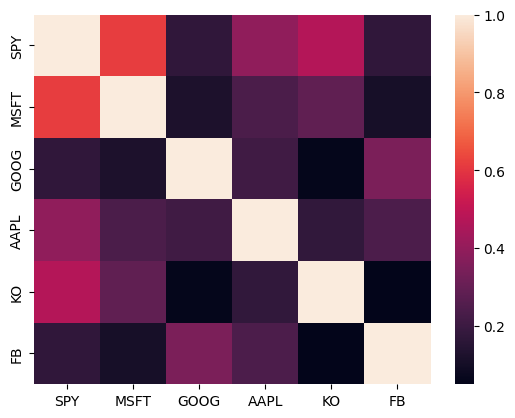

In [105]:
import seaborn as sns
sp500_filtered = sp500[['SPY', 'MSFT', 'GOOG', 'AAPL', 'KO', 'FB']]
sns.heatmap(sp500_filtered.corr())

## Scatterplot

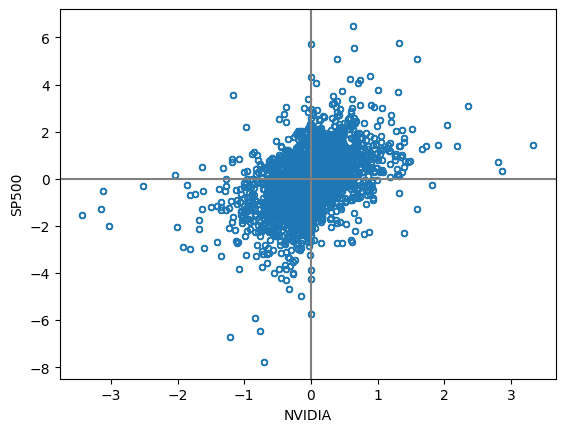

In [125]:
ax = sp500.plot.scatter(x='NVDA', y='SPY', marker = '$\u25EF$')
ax.set_xlabel('NVIDIA')
ax.set_ylabel('SP500')
ax.axhline(0, color = 'grey')
ax.axvline(0, color = 'grey')

# Distributions

In [131]:
from scipy import stats
from matplotlib import pyplot as plt

((array([-2.46203784, -2.12570747, -1.93122778, -1.79044653, -1.67819304,
         -1.58381122, -1.50174123, -1.42869743, -1.36256869, -1.30191411,
         -1.24570419, -1.19317644, -1.14374949, -1.09696931, -1.05247413,
         -1.00997067, -0.96921765, -0.93001393, -0.89218993, -0.85560121,
         -0.82012357, -0.78564937, -0.75208458, -0.71934648, -0.68736185,
         -0.65606548, -0.62539893, -0.59530962, -0.56574992, -0.53667655,
         -0.50804994, -0.47983378, -0.45199463, -0.42450149, -0.39732558,
         -0.37044003, -0.34381966, -0.31744076, -0.29128096, -0.26531902,
         -0.23953472, -0.21390872, -0.18842244, -0.16305799, -0.13779803,
         -0.1126257 , -0.08752455, -0.06247843, -0.03747145, -0.01248789,
          0.01248789,  0.03747145,  0.06247843,  0.08752455,  0.1126257 ,
          0.13779803,  0.16305799,  0.18842244,  0.21390872,  0.23953472,
          0.26531902,  0.29128096,  0.31744076,  0.34381966,  0.37044003,
          0.39732558,  0.42450149,  0.

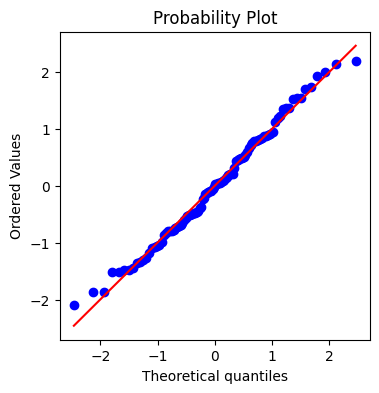

In [135]:
fig, ax = plt.subplots(figsize=(4, 4))
norm_sample = stats.norm.rvs(size=100) # generates numbers from a standard normal distribution....
stats.probplot(norm_sample, plot=ax)

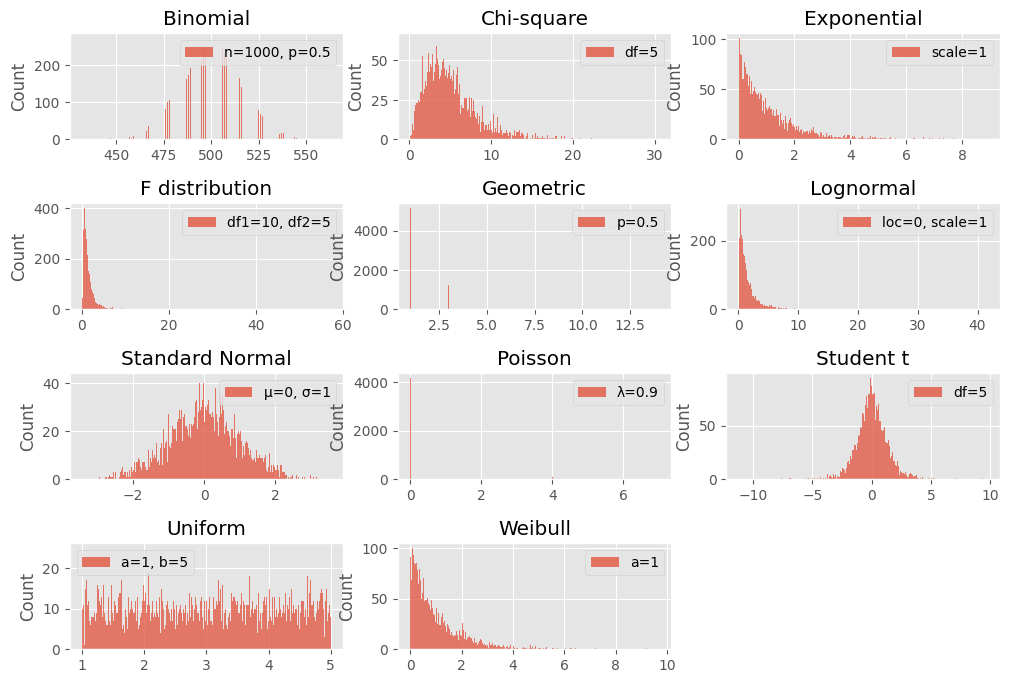

In [138]:
# overview of various statistical distributions

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# parameters
sample = 10000 #sample size
loc = 0
scale = 1
shape = 2
a = 1
b = 5
n = 1000
p = 0.5
alpha = (10, 10, 3)
dfnum = 10
dfden = 5
nbins = int(sample / 10)
df = 5
lam = 0.9

distributions = [
    ['Binomial',  f'n={n}, p={p}'                   , np.random.binomial(n, p, sample)      ],
    ['Chi-square', f'df={df}'                       , np.random.chisquare(df, sample)       ],
    ['Exponential', f'scale={scale}'                , np.random.exponential(scale, sample)  ],
    ['F distribution', f'df1={dfnum}, df2={dfden}'  , np.random.f(dfnum, dfden, sample)     ],
    ['Geometric', f'p={p}'                          , np.random.geometric(p, sample)        ],
    ['Lognormal', f'loc={loc}, scale={scale}'       , np.random.lognormal(loc, scale, sample)],
    ['Standard Normal', 'μ=0, σ=1'                  , np.random.standard_normal(sample)     ],
    ['Poisson', f'λ={lam}'                          , np.random.poisson(lam, sample)        ],
    ['Student t', f'df={df}'                        , np.random.standard_t(df, sample)      ],
    ['Uniform', f'a={a}, b={b}'                     , np.random.uniform(a,b, sample)        ],
    ['Weibull', f'a={a}'                            , np.random.weibull(a, sample)          ]
]

num = len(distributions)
nrows = 4
ncols = 3

# Generating the graph
plt.style.use('ggplot')

fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (4 * ncols, 2 * nrows))
plt.subplots_adjust(hspace = 0.6) #the amount of space reserved between plots
i = 0
for row in range(nrows):
    for col in range(ncols):
            dist = distributions[i][2]
            sns.histplot(dist, bins = nbins, ax = ax[row][col], label  = distributions[i][1] )
            ax[row][col].set_title(distributions[i][0])
            ax[row][col].legend()
            i += 1
            if len(distributions) < nrows * ncols and i == num: 
                fig.delaxes(ax[nrows -1 , ncols - 1])
                break #if there were not a break the index would go out of range in case of even numbered list
